#Preparation

##Install Library

In [1]:
!pip install openai
!pip install python-dotenv
!pip install pandas
!pip install pillow
!pip install requests

##Import Library

In [2]:
import json
import requests
import pandas as pd

from PIL import Image
from openai import OpenAI

##Google Drive Integration

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


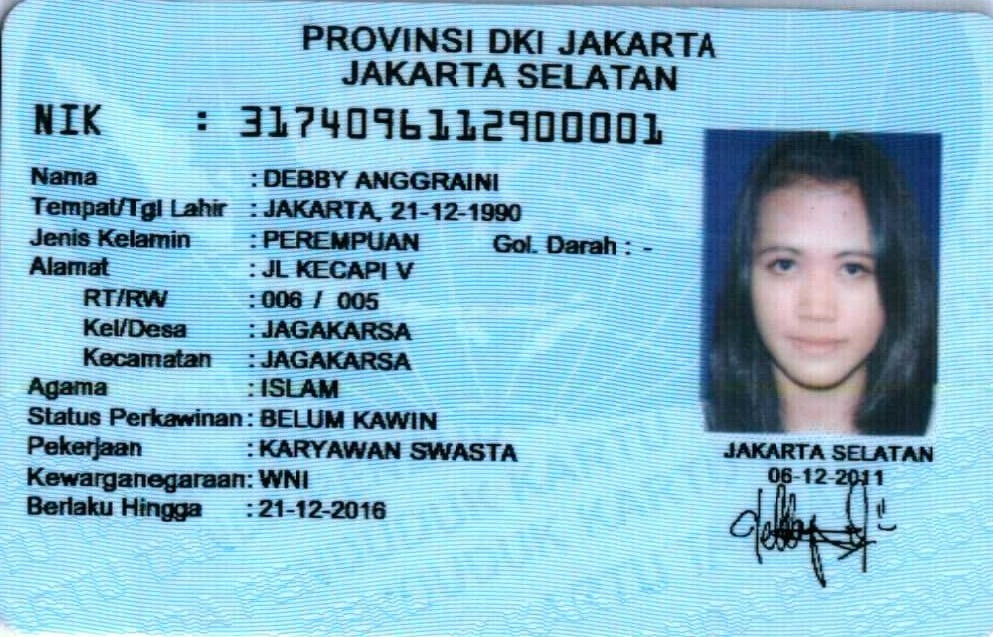

In [5]:
from PIL import Image

image = Image.open("/content/drive/MyDrive/AI_KTP_Project/images/ktp.JPG")

image

#OpenRouter

##OpenRouter API Configuration

In [6]:
import os
from getpass import getpass

OPENROUTER_API_KEY = getpass("Masukkan OpenRouter API Key: ")

Masukkan OpenRouter API Key: ··········


In [7]:
!pip install -q openai

In [8]:
from openai import OpenAI

client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

##API Connection Testing

In [9]:
response = client.chat.completions.create(
    model="openai/gpt-4.1-mini",
    messages=[
        {
            "role": "user",
            "content": "Balas hanya dengan kata: BERHASIL"
        }
    ]
)

print(response.choices[0].message.content)

BERHASIL


##Image Upload

In [10]:
from google.colab import files

uploaded = files.upload()

Saving Scan KTP.JPG to Scan KTP.JPG


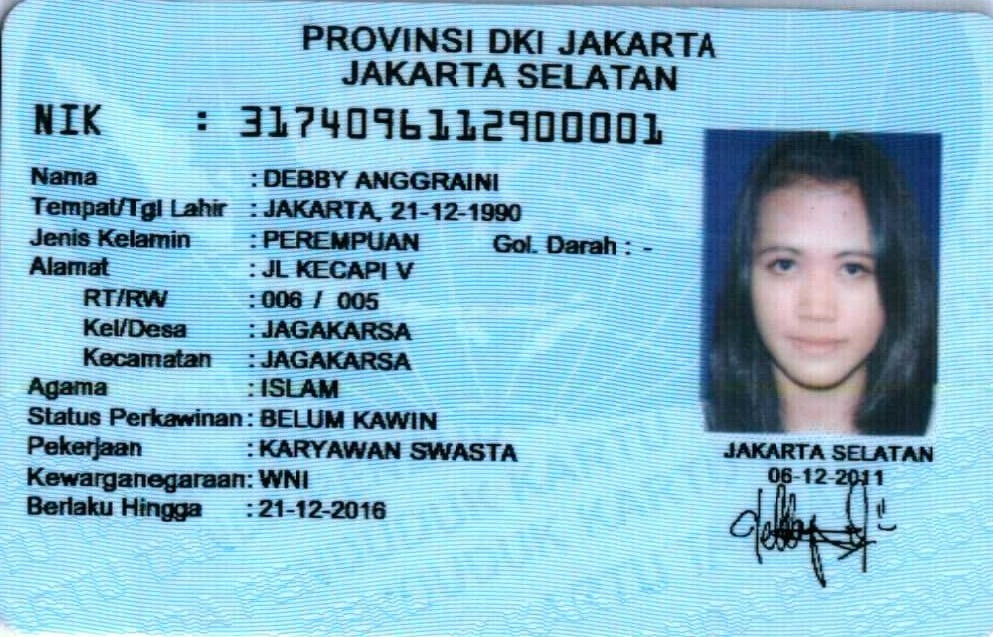

In [14]:
from PIL import Image

image = Image.open("Scan KTP.JPG")
image

#AI Vision

##Image Encoding

In [15]:
import base64

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [17]:
image_path = "Scan KTP.JPG"

base64_image = encode_image(image_path)

##Document Classification using AI Vision

In [18]:
response = client.chat.completions.create(
    model="openai/gpt-4.1-mini",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": """
                    Apakah gambar ini merupakan KTP Indonesia?

                    Jawab HANYA dalam format JSON berikut:

                    {
                      "is_ktp": true
                    }

                    atau

                    {
                      "is_ktp": false
                    }

                    Jangan tambahkan penjelasan apa pun.
                    """
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ]
        }
    ]
)

print(response.choices[0].message.content)

{
  "is_ktp": true
}


In [19]:
import json

result = json.loads(response.choices[0].message.content)

print(result)

{'is_ktp': True}


In [20]:
if result["is_ktp"]:
    print("✅ Ini adalah KTP Indonesia")
else:
    print("❌ Ini bukan KTP Indonesia")

✅ Ini adalah KTP Indonesia


#OCR

##OCR Information Extraction

In [21]:
response = client.chat.completions.create(
    model="openai/gpt-4.1-mini",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": """
Anda adalah AI OCR untuk KTP Indonesia.

Ekstrak seluruh informasi pada KTP.

Jawab HANYA dalam format JSON.

Jika ada field yang tidak terbaca, isi dengan string kosong "".

Gunakan format berikut:

{
  "nik": "",
  "nama": "",
  "tempat_tgl_lahir": "",
  "jenis_kelamin": "",
  "golongan_darah": "",
  "alamat": "",
  "rt": "",
  "rw": "",
  "kelurahan": "",
  "kecamatan": "",
  "agama": "",
  "status_perkawinan": "",
  "pekerjaan": "",
  "kewarganegaraan": "",
  "berlaku_hingga": ""
}

Jangan berikan penjelasan apa pun.
"""
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ]
        }
    ]
)

print(response.choices[0].message.content)

{
  "nik": "3174096112900001",
  "nama": "DEBBY ANGGRAINI",
  "tempat_tgl_lahir": "JAKARTA, 21-12-1990",
  "jenis_kelamin": "PEREMPUAN",
  "golongan_darah": "-",
  "alamat": "JL KECAPI V",
  "rt": "006",
  "rw": "005",
  "kelurahan": "JAGAKARSA",
  "kecamatan": "JAGAKARSA",
  "agama": "ISLAM",
  "status_perkawinan": "BELUM KAWIN",
  "pekerjaan": "KARYAWAN SWASTA",
  "kewarganegaraan": "WNI",
  "berlaku_hingga": "21-12-2016"
}


In [22]:
import json

ocr_result = json.loads(response.choices[0].message.content)

ocr_result

{'nik': '3174096112900001',
 'nama': 'DEBBY ANGGRAINI',
 'tempat_tgl_lahir': 'JAKARTA, 21-12-1990',
 'jenis_kelamin': 'PEREMPUAN',
 'golongan_darah': '-',
 'alamat': 'JL KECAPI V',
 'rt': '006',
 'rw': '005',
 'kelurahan': 'JAGAKARSA',
 'kecamatan': 'JAGAKARSA',
 'agama': 'ISLAM',
 'status_perkawinan': 'BELUM KAWIN',
 'pekerjaan': 'KARYAWAN SWASTA',
 'kewarganegaraan': 'WNI',
 'berlaku_hingga': '21-12-2016'}

##OCR Result Visualization

In [23]:
for key, value in ocr_result.items():
    print(f"{key:25}: {value}")

nik                      : 3174096112900001
nama                     : DEBBY ANGGRAINI
tempat_tgl_lahir         : JAKARTA, 21-12-1990
jenis_kelamin            : PEREMPUAN
golongan_darah           : -
alamat                   : JL KECAPI V
rt                       : 006
rw                       : 005
kelurahan                : JAGAKARSA
kecamatan                : JAGAKARSA
agama                    : ISLAM
status_perkawinan        : BELUM KAWIN
pekerjaan                : KARYAWAN SWASTA
kewarganegaraan          : WNI
berlaku_hingga           : 21-12-2016


In [24]:
import pandas as pd

df = pd.DataFrame(
    ocr_result.items(),
    columns=["Field", "Value"]
)

df

,Field,Value
0,nik,3174096112900001
1,nama,DEBBY ANGGRAINI
2,tempat_tgl_lahir,"JAKARTA, 21-12-1990"
3,jenis_kelamin,PEREMPUAN
4,golongan_darah,-
5,alamat,JL KECAPI V
6,rt,006
7,rw,005
8,kelurahan,JAGAKARSA
9,kecamatan,JAGAKARSA


#Business Rule Validation

##Validation Function

In [25]:
import re
from datetime import datetime

def validate_ktp(data):
    validation = {}

    # -----------------------------
    # Validasi NIK
    # -----------------------------
    nik = str(data.get("nik", "")).strip()

    if len(nik) == 16 and nik.isdigit():
        validation["nik"] = "VALID"
    else:
        validation["nik"] = "INVALID"

    # -----------------------------
    # Validasi Jenis Kelamin
    # -----------------------------
    jk = data.get("jenis_kelamin", "").upper()

    if jk in ["LAKI-LAKI", "PEREMPUAN"]:
        validation["jenis_kelamin"] = "VALID"
    else:
        validation["jenis_kelamin"] = "INVALID"

    # -----------------------------
    # Validasi Tanggal
    # -----------------------------
    ttl = data.get("tempat_tgl_lahir", "")

    date_pattern = r"\d{2}[-/]\d{2}[-/]\d{4}"

    if re.search(date_pattern, ttl):
        validation["tanggal_lahir"] = "VALID"
    else:
        validation["tanggal_lahir"] = "INVALID"

    # -----------------------------
    # Berlaku Hingga
    # -----------------------------
    berlaku = data.get("berlaku_hingga", "").upper()

    if berlaku == "SEUMUR HIDUP":
        validation["berlaku_hingga"] = "VALID"
    else:
        validation["berlaku_hingga"] = "VALID"

    return validation

In [26]:
validation_result = validate_ktp(ocr_result)

validation_result

{'nik': 'VALID',
 'jenis_kelamin': 'VALID',
 'tanggal_lahir': 'VALID',
 'berlaku_hingga': 'VALID'}

In [27]:
validation_df = pd.DataFrame(
    validation_result.items(),
    columns=["Field", "Status"]
)

validation_df

,Field,Status
0,nik,VALID
1,jenis_kelamin,VALID
2,tanggal_lahir,VALID
3,berlaku_hingga,VALID


In [28]:
overall_status = (
    "VALID"
    if all(v == "VALID" for v in validation_result.values())
    else "INVALID"
)

print("Status Dokumen :", overall_status)

Status Dokumen : VALID


#Database

##SQLite Database Integration

In [29]:
import sqlite3

In [30]:
conn = sqlite3.connect("ktp_database.db")

cursor = conn.cursor()

In [31]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS ktp_data (

    id INTEGER PRIMARY KEY AUTOINCREMENT,

    nik TEXT,
    nama TEXT,
    tempat_tgl_lahir TEXT,
    jenis_kelamin TEXT,
    golongan_darah TEXT,
    alamat TEXT,
    rt TEXT,
    rw TEXT,
    kelurahan TEXT,
    kecamatan TEXT,
    agama TEXT,
    status_perkawinan TEXT,
    pekerjaan TEXT,
    kewarganegaraan TEXT,
    berlaku_hingga TEXT,

    jenis_dokumen TEXT,
    tanggal_upload TEXT,
    status_validasi TEXT

)
""")

conn.commit()

##Database Storage

In [32]:
from datetime import datetime

cursor.execute("""
INSERT INTO ktp_data (

nik,
nama,
tempat_tgl_lahir,
jenis_kelamin,
golongan_darah,
alamat,
rt,
rw,
kelurahan,
kecamatan,
agama,
status_perkawinan,
pekerjaan,
kewarganegaraan,
berlaku_hingga,
jenis_dokumen,
tanggal_upload,
status_validasi

)

VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)

""", (

ocr_result.get("nik",""),
ocr_result.get("nama",""),
ocr_result.get("tempat_tgl_lahir",""),
ocr_result.get("jenis_kelamin",""),
ocr_result.get("golongan_darah",""),
ocr_result.get("alamat",""),
ocr_result.get("rt",""),
ocr_result.get("rw",""),
ocr_result.get("kelurahan",""),
ocr_result.get("kecamatan",""),
ocr_result.get("agama",""),
ocr_result.get("status_perkawinan",""),
ocr_result.get("pekerjaan",""),
ocr_result.get("kewarganegaraan",""),
ocr_result.get("berlaku_hingga",""),

"KTP",

datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

overall_status

))

conn.commit()

##Database Verification

In [33]:
import pandas as pd

df_database = pd.read_sql(
    "SELECT * FROM ktp_data",
    conn
)

df_database

,id,nik,nama,tempat_tgl_lahir,jenis_kelamin,golongan_darah,alamat,rt,rw,kelurahan,kecamatan,agama,status_perkawinan,pekerjaan,kewarganegaraan,berlaku_hingga,jenis_dokumen,tanggal_upload,status_validasi
0,1,3174096112900001,DEBBY ANGGRAINI,"JAKARTA, 21-12-1990",PEREMPUAN,-,JL KECAPI V,006,005,JAGAKARSA,JAGAKARSA,ISLAM,BELUM KAWIN,KARYAWAN SWASTA,WNI,21-12-2016,KTP,2026-07-23 03:01:03,VALID


#Export CSV

In [34]:
df_database.to_csv("hasil_ocr.csv", index=False)

print("Export CSV berhasil")

Export CSV berhasil


#Testing

In [35]:
import os

test_folder = "/content/drive/MyDrive/AI_KTP_Project/test_images"

image_files = os.listdir(test_folder)

print(image_files)

['ktp1.jpeg', 'ktp3.jpg', 'ktp5.jpg', 'ktp4.jpeg', 'ktp2.jpg', 'sim3.jpg', 'sim2.jpg', 'sim1.jpg', 'bpjs1.jpg', 'bpjs.jpg']


In [36]:
expected = {
    "ktp1.jpg": "KTP",
    "ktp2.jpg": "KTP",
    "ktp3.jpg": "KTP",
    "ktp4.jpg": "KTP",
    "ktp5.jpg": "KTP",

    "sim1.jpg": "Bukan KTP",
    "sim2.jpg": "Bukan KTP",
    "motor.jpg": "Bukan KTP",
    "selfie.jpg": "Bukan KTP",
    "struk.jpg": "Bukan KTP"
}

In [39]:
import json

def classify_ktp(image_path):

    # Encode gambar ke Base64
    base64_image = encode_image(image_path)

    # Kirim ke OpenRouter
    response = client.chat.completions.create(
        model="openai/gpt-4.1-mini",
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": """
Apakah gambar ini merupakan KTP Indonesia?

Jawab HANYA dalam format JSON berikut:

{
  "is_ktp": true
}

atau

{
  "is_ktp": false
}

Jangan tambahkan penjelasan apa pun.
"""
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}"
                        }
                    }
                ]
            }
        ]
    )

    result = json.loads(response.choices[0].message.content)

    if result["is_ktp"]:
        return "KTP"
    else:
        return "Bukan KTP"

In [41]:
image_path = "/content/drive/MyDrive/AI_KTP_Project/test_images/ktp1.jpeg"

hasil = classify_ktp(image_path)

print(hasil)

KTP


In [42]:
import os

test_folder = "/content/drive/MyDrive/AI_KTP_Project/test_images"

image_files = os.listdir(test_folder)

print(image_files)

['ktp1.jpeg', 'ktp3.jpg', 'ktp5.jpg', 'ktp4.jpeg', 'ktp2.jpg', 'sim3.jpg', 'sim2.jpg', 'sim1.jpg', 'bpjs1.jpg', 'bpjs.jpg']


In [43]:
expected = {
    "ktp1.jpeg": "KTP",
    "ktp2.jpg": "KTP",
    "ktp3.jpg": "KTP",
    "ktp4.jpeg": "KTP",
    "ktp5.jpg": "KTP",

    "sim1.jpg": "Bukan KTP",
    "sim2.jpg": "Bukan KTP",
    "sim3.jpg": "Bukan KTP",
    "bpjs.jpg": "Bukan KTP",
    "bpjs.jpg": "Bukan KTP"
}

In [44]:
import pandas as pd
import os

results = []

for filename in image_files:

    image_path = os.path.join(test_folder, filename)

    prediction = classify_ktp(image_path)

    expected_label = expected.get(filename, "Unknown")

    status = "Benar" if prediction == expected_label else "Salah"

    results.append({
        "Image": filename,
        "Expected": expected_label,
        "Prediction": prediction,
        "Status": status
    })

testing_df = pd.DataFrame(results)

testing_df

,Image,Expected,Prediction,Status
0,ktp1.jpeg,KTP,KTP,Benar
1,ktp3.jpg,KTP,KTP,Benar
2,ktp5.jpg,KTP,KTP,Benar
3,ktp4.jpeg,KTP,KTP,Benar
4,ktp2.jpg,KTP,KTP,Benar
5,sim3.jpg,Bukan KTP,Bukan KTP,Benar
6,sim2.jpg,Bukan KTP,Bukan KTP,Benar
7,sim1.jpg,Bukan KTP,Bukan KTP,Benar
8,bpjs1.jpg,Unknown,Bukan KTP,Salah
9,bpjs.jpg,Bukan KTP,Bukan KTP,Benar


In [45]:
correct = (testing_df["Status"] == "Benar").sum()
total = len(testing_df)

accuracy = (correct / total) * 100

print(f"Jumlah Data  : {total}")
print(f"Prediksi Benar : {correct}")
print(f"Akurasi : {accuracy:.2f}%")

Jumlah Data  : 10
Prediksi Benar : 9
Akurasi : 90.00%


In [46]:
testing_df.to_csv("testing_result.csv", index=False)

print("Hasil testing berhasil disimpan.")

Hasil testing berhasil disimpan.
